# 5 - Chapitre 5 - NumPy et Matplotlib

[NumPy](https://numpy.org/) et [Matplotlib](https://matplotlib.org/stable/) sont deux bibliothèques essentielles pour le calcul scientifique et la visualisation de données en Python. Elles permettent de manipuler efficacement des tableaux de données et de créer des graphiques pour mieux comprendre et présenter vos résultats.

## NumPy

Quand vous travaillez avec beaucoup de données numériques (par exemple des mesures, des séries temporelles, des capteurs…), les listes Python classiques peuvent devenir lentes et peu pratiques. C’est là qu’intervient NumPy, un module puissant conçu pour les calculs numériques rapides et efficaces.

Avec NumPy, on utilise des tableaux (ou arrays) : ce sont comme des listes, mais en plus rapide, plus léger et mieux adapté aux calculs mathématiques.

#### Différence entre listes et arrays

A l'inverse des listes, il est possible d'effectuer des opérations mathématiques sur des arrays de **manière vectorisée**, c'est-à-dire que l'on peut appliquer une opération à tous les éléments d'un array en une seule instruction. On n'utilise pas de boucle explicite (comme `for` ou `while`) pour itérer sur les éléments. NumPy utilise des **fonctions vectorisées** qui sont optimisées pour effectuer des opérations sur des tableaux de manière efficace. Ces fonctions sont codées en C et sont donc beaucoup plus rapides que les boucles Python classiques.

Par exemple, si on a un array `a`, on peut faire `a + 1` pour ajouter 1 à chaque élément de l'array. C'est beaucoup plus rapide que de faire une boucle sur chaque élément de la liste.

### 1. Création d'un array

Il existe plusieurs façons de créer un array NumPy. `numpy.array()` permet de créer un array à partir d'une liste Python. Mais numpy propose aussi des fonctions pour créer des arrays de zéros, de uns, ou d'une séquence de nombres.

### 2. Operations sur les arrays

Les opérations sont **vectorisées**, c'est-à-dire qu'elles s'appliquent à tous les éléments de l'array. Par exemple, si on a un array `a`, on peut faire `a + 1` pour ajouter 1 à chaque élément de l'array. C'est beaucoup plus rapide que de faire une boucle sur chaque élément de la liste.

### 3. Reshape

On peut changer la forme d'un array avec la méthode `reshape()`. Par exemple, si on a un array de 12 éléments, on peut le transformer en un tableau 3x4 avec `a.reshape(3, 4)`. Cela ne change pas les données, juste la façon dont elles sont organisées.

### 4. Indexation

On peut accéder aux éléments d'un array avec des indices, comme pour les listes. Mais NumPy permet aussi de faire du **slicing** multidimensionnel, c'est-à-dire qu'on peut sélectionner des sous-tableaux en spécifiant des tranches pour chaque dimension.

### 5. Les fonctions calculatoire & statistiques

NumPy propose de nombreuses fonctions mathématiques pour effectuer des calculs sur les arrays. Par exemple, `numpy.mean()` calcule la moyenne, `numpy.std()` calcule l'écart type, et `numpy.sum()` calcule la somme des éléments d'un array. Ces fonctions sont optimisées pour être rapides et efficaces.

### 6. Masques (filtrage)

On peut créer des masques pour filtrer les données d'un array. Par exemple, si on a un array `a`, on peut créer un masque pour sélectionner seulement les éléments supérieurs à 5 avec `a[a > 5]`. Cela renvoie un nouvel array contenant seulement les éléments qui satisfont la condition.

NumPy permet également avec np.where de trouver les indices des éléments qui satisfont une condition. Par exemple, `np.where(a > 5)` renvoie les indices des éléments de `a` qui sont supérieurs à 5. Cela peut être utile pour effectuer des opérations conditionnelles sur les données.

### 7. Broadcasting

Le **broadcasting** est une fonctionnalité puissante de NumPy qui permet d'effectuer des opérations sur des arrays de différentes formes.



### 1. Création d'un array

In [1]:
## NumPy
import numpy as np

# On utilisera toujours le module numpy sous le nom np: standard

# Créer un tableau
mon_tableau = np.array([1, 2, 3, 4, 5])
mon_tableau

array([1, 2, 3, 4, 5])

In [2]:
# A partir d'une liste Python
np.array([1, 2, 3, 4, 5])

array([1, 2, 3, 4, 5])

In [3]:
# Il est conseillé d'utiliser les array numpy uniquement avec des types homogènes
np.array([1, 1.0, 1.5, "toto"]) * 2

TypeError: The 'out' kwarg is necessary. Use numpy.strings.multiply without it.

#### On peut créer des tableaux de plusieurs dimensions

Tableaux 2D : des “tableaux de tableaux”

In [ ]:
matrice = np.array([[1, 2, 3], [4, 5, 6]])
matrice

array([[1, 2, 3],
       [4, 5, 6]])

#### Ou encore utiliser des fonctions standards NumPy

In [ ]:
# Initialiser un tableau avec des zéros
np.zeros(5)  # n: nombre de zéros

array([0., 0., 0., 0., 0.])

In [ ]:
# Initialiser un tableau avec des uns
np.ones(3)  # n: nombre de uns

array([1., 1., 1.])

In [ ]:
# Initialiser un tableau de nombres aléatoires
generator = np.random.default_rng(
    seed=42
)  # Initialiser le générateur de nombres aléatoires
generator.random(5)  # n: nombre de valeurs aléatoires

array([0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735])

In [ ]:
# Initialiser une suite de nombres
# start: début, stop: fin
np.arange(start=0, stop=10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [ ]:
np.arange(0, 10, 2)  # start: début, stop: fin, step: pas

array([0, 2, 4, 6, 8])

In [ ]:
# Ou encore initialiser un tableau avec des valeurs régulièrement espacées
# start: début, stop: fin, n: nombre de valeurs
np.linspace(0, 1, 5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

#### Accéder aux éléments

In [ ]:
a = np.array([10, 20, 30, 40])
print(a[0])  # 10
print(a[-1])  # 40

10
40


In [ ]:
# Pour les tableaux 2D :
mat = np.array([[1, 2], [3, 4]])
print(mat[1][0])  # 3

3


### 2. Operations sur les arrays

**Les opérations arithmétiques: vectorisées !**

In [ ]:
# Contrairement aux listes classiques, ces tableaux peuvent être utilisés directement dans des opérations mathématiques.
# Les opérations sont appliquées à tous les éléments sans boucle
a = np.array([1, 2, 3])
a + 2

array([3, 4, 5])

In [ ]:
[1, 2, 3] + 2  # Erreur

TypeError: can only concatenate list (not "int") to list

In [ ]:
a * 2

array([2, 4, 6])

In [ ]:
[1, 2, 3, 4, 5] * 2  # Avec une liste, on concatène!

[1, 2, 3, 4, 5, 1, 2, 3, 4, 5]

In [ ]:
array1 = np.array([1, 2, 3, 4])
array2 = np.array([5, 6, 7, 8])

# Multiplication vectorisée des deux tableaux
result = array1 * array2
result

array([ 5, 12, 21, 32])

In [ ]:
# Tri
a = np.array([3, 1, 2, 4, 5, -1, 10, -5])

# Tri croissant
np.sort(a)

array([-5, -1,  1,  2,  3,  4,  5, 10])

In [ ]:
# Tri décroissant
np.sort(a)[::-1]

array([10,  5,  4,  3,  2,  1, -1, -5])

## Exercice 🐍 - Création d'array et opérations standards

L'objectif de cet exercice est de vous familiariser avec la création d'array NumPy et les opérations arithmétiques de base.

## Objectifs:
- Apprendre à créer des arrays NumPy
- Apprendre à effectuer des opérations arithmétiques sur les arrays

1. Créez un array NumPy a contenant les entiers de 0 à 999.
2. Calculez la somme de tous les éléments de a.
3. Créez l'array b en multipliant chaque élément de a par 2.
4. Calculez la sommes et la moyenne de b.

Si vous avez déjà fini:

- Calculez la somme des nombres de 1 à 10 000 000 avec NumPy et avec une liste Python classique. Comparez les temps d'exécution.
- Passez de 10 000 000 à 100 000 000 et comparez les temps d'exécution.

In [ ]:
# A vous de jouer!

### 3. Reshape
On peut redimensionner, remodeler et concaténer des tableaux NumPy pour répondre à vos besoins spécifiques.

C'est très utile pour préparer vos données avant de les analyser ou de les visualiser !

In [ ]:
a = np.array([[1, 2], [3, 4]])
a

array([[1, 2],
       [3, 4]])

In [ ]:
# On change la forme du tableau et le transforme
# en array de dimension 1
a.reshape(1, 4)

array([[1, 2, 3, 4]])

In [ ]:
a.reshape(4, 1)  # On change la forme du tableau

array([[1],
       [2],
       [3],
       [4]])

### 4. Indexation

In [ ]:
a = np.array([1, 2, 3, 4, 5])
a[1:4]  # On slice le tableau

array([2, 3, 4])

In [ ]:
b = np.array([[1, 2], [3, 4]])

b[0, 1]  # On slice le tableau

np.int64(2)

### 5. Les fonctions calculatoire & statistiques


In [ ]:
a = np.linspace(0, 10, 5)
a

array([ 0. ,  2.5,  5. ,  7.5, 10. ])

In [ ]:
# Somme
np.sum(a)

np.float64(25.0)

In [ ]:
# Moyenne
np.mean(a)

np.float64(5.0)

In [ ]:
# Ecart-type
np.std(a)

np.float64(3.5355339059327378)

In [ ]:
# Min & Max
print("Min:", np.min(a), "Max:", np.max(a))

Min: 0.0 Max: 10.0


In [ ]:
# On peut calculer des sommes
a = np.array([[1, 2, 3, 4]])
a.sum()  # Somme de tous les éléments

np.int64(10)

In [ ]:
# Des sommes cumulées
a.cumsum()  # Somme cumulée

array([ 1,  3,  6, 10])

## Exercice 🐍 - Reshape et calculs statistiques

L'objectif de cet exercice est de vous familiariser avec la fonction reshape de NumPy et les calculs statistiques.

## Objectifs:
- Apprendre à utiliser la fonction reshape de NumPy
- Apprendre à effectuer des calculs statistiques sur les arrays

## Enoncé

1. Créez un array a contenant les entiers de 1 à 12.
2. Utilisez reshape pour transformer a en un tableau 3x4.
3. Calculez la somme des éléments de chaque colonne.
* On pourra utiliser: np.sum(a, axis=0)

4. Calculez la moyenne et l'écart type des éléments de chaque ligne.
* On pourra utiliser: np.mean(a, axis=1) et np.std(a, axis=1)

5. Vérifier à la main le calcul des moyennes!

In [ ]:
# A vous de jouer!

### 6. Masques (filtrage)

In [ ]:
a = np.arange(0, 20)

# On va récupérer que les données supérieures à 10
a[a > 10]

array([11, 12, 13, 14, 15, 16, 17, 18, 19])

In [ ]:
# Décomposons:
a > 10  # On crée un tableau de booléens

array([False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

In [ ]:
# On applique le mask
# sur le tableau d'origine
a[a > 10]

array([11, 12, 13, 14, 15, 16, 17, 18, 19])

In [ ]:
a = np.array([1, 2, 3])

a[np.array([True, False, True])]  # On slice le tableau avec des booléens

array([1, 3])

In [ ]:
# Calcul de la moyenne sur le
# sous ensemble
np.mean(a[a > 10])

/home/lgiron/lab_perso/python_course/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lgiron/lab_perso/python_course/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


np.float64(nan)

In [ ]:
# NumPy permet de faire des opérations sur les tableaux de manière vectorisée
np.where(a >= 2)  # On récupère les indices des valeurs supérieures à 2

(array([1, 2]),)

Cela fonctionne aussi avec des strings

numpy propose np.char pour manipuler des strings


In [ ]:
a_str = np.array(["Rouen", "Paris", "Lille", "Marseille"])
# On va calculer la longueur de chaque ville, vectoriellement
np.char.str_len(a_str)

array([5, 5, 5, 9])

In [ ]:
# On va récupérer les villes qui commencent par un R
a_str[np.char.startswith(a_str, "R")]

array(['Rouen'], dtype='<U9')

## Exercice 🐍 - Masks

L'objectif de cet exercice est de vous familiariser avec les masks NumPy.

## Objectifs:
- Apprendre à utiliser les masks NumPy
- Apprendre à filtrer les données avec les masks
- Apprendre à effectuer des opérations arithmétiques sur les masks

## Avec des nombres

1. Créez un array a contenant les entiers de 1 à 20.
2. Utilisez un masque pour sélectionner tous les éléments pairs de a.
3. Créez un array b (en faisant une copie de a) et remplacez tous les éléments impairs de b par 0.
4. Calculez la somme des éléments pairs avec a et b.

## Avec des chaînes de caractères

1. Créez un array contenant les chaînes de caractères suivantes: "nuclear", "wind", "solar", "gas", "hydrogen", "hydrolic".

2. Utilisez un masque pour sélectionner les chaînes de caractères commencant par "h" ou les chaînes de caractères contenant "wind".
  - Pour utiliser plusieurs conidtions, on utilise le symbole | (ou) et & (et) avec des

3. Créer un tableau contenant les longueurs de chaque chaîne de caractères.

4. Utilisez un masque pour sélectionner les éléments content des énergies renouvelables (qui contiennent "wind", "solar", "hydrolic") et donnez la longueur du tableau.
  - On utilisera np.isin()

In [ ]:
# A vous de jouer!

### 7. Broadcasting

In [ ]:
a = np.array([1, 2, 3])
b = np.array([[4, 5], [6, 7]])

In [ ]:
a

array([1, 2, 3])

In [ ]:
b

array([[4, 5],
       [6, 7]])

In [4]:
a + b  # On ne peut pas additionner un tableau 1D et un tableau 2D

NameError: name 'a' is not defined

In [5]:
# Avec le broadcasting, on peut faire des opérations entre tableaux de
# dimensions différentes
a = np.array([[1, 2], [3, 4]])
b = np.array([[5], [6]])
print("Shape a:", a.shape, "Shape b:", b.shape)
a + b  # On additionne les tableaux

Shape a: (2, 2) Shape b: (2, 1)


array([[ 6,  7],
       [ 9, 10]])

## Exercice 🐍 - Analyse d'une grille de températures

L'objectif de cet exercice est de vous familiariser avec l'analyse de données en utilisant NumPy.

## Objectifs:
- Apprendre à créer une grille de données
- Apprendre à utiliser reshape pour transformer une grille en tableau 1D
- Apprendre à utiliser les masques pour filtrer les données
- Apprendre à utiliser le broadcasting pour effectuer des opérations sur les données
- Apprendre à calculer des statistiques sur les données

## Enoncé

Contexte : Vous disposez d'une grille de températures représentant une région géographique. Chaque élément de la grille représente la température en degrés Celsius d'une zone spécifique.

Cette grille est de format: 10 x 5 x 2: la dernière dimension représente les températures pour trois moments de la journée (matin, soir).

1. Utilisez reshape pour transformer cette grille en un tableau 2D.
    - La première dimension représente les zones géographiques (10 zones).
    - La deuxième dimension représente les températures pour chaque zone (10 températures car on ne fera pas de distinction entre matin et soir).
2. Calculez la température moyenne de la grille.
3. Utilisez un masque pour identifier les zones où la température est inférieure à 0°C.

Vous devez maintenant convertir les températures de Celsius à Kelvin.
0°C correspond à 273.15 K.

4. Convertissez toutes les températures de Celsius à Kelvin.
5. Calculez la température moyenne en Kelvin.

Si vous avez déjà fini:

Analyse des variations de température :

6. Calculez la variation de température (différence entre la température du soir et du matin) pour chaque zone géographique.

7. Identifiez les zones où cette variation est supérieure à 10°C.

8. Donnez les index de ces zones: l'indice représente la position de la zone dans le tableau 2D.


## Matplotlib

Lorsque vous travaillez avec des données numériques, il est souvent essentiel de les visualiser pour mieux les comprendre et les présenter. C'est là qu'intervient Matplotlib, une bibliothèque puissante et flexible pour créer des graphiques et des visualisations en Python. Elle est particulièrement utile pour les scientifiques, les ingénieurs et les analystes de données.

Matplotlib est flexible et permet de créer une grande variété de graphiques, des plus simples aux plus complexes. Il est largement utilisé dans la communauté scientifique pour ses capacités de personnalisation.

### 1. Création de graphiques simples

Matplotlib permet de créer facilement des graphiques à partir de données. La fonction ``plot()`` est utilisée pour tracer des courbes 2D simples. Vous pouvez personnaliser vos graphiques en ajoutant des titres, des étiquettes aux axes, des légendes, etc.

### 2. Les différents types de graphiques
Matplotlib propose une variété de types de graphiques, notamment :
- Graphiques en ligne (line plots): ``plot()``
- Graphiques à barres (bar plots): ``bar()``
- Graphiques à secteurs (pie charts): ``pie()``
- Graphiques en nuage de points (scatter plots): ``scatter()``
- Graphiques en histogramme (histograms): ``hist()``

Chaque type de graphique est dédié à un type de données spécifique! En effet, on utilisera des ``plot`` pour visualiser des séries temporelles, des ``scatter`` pour visualiser la relation entre deux variables, et des ``hist`` pour visualiser la distribution d'une variable.
Les ``pie`` sont souvent utilisés pour représenter des proportions, mais ils sont moins recommandés car ils peuvent être difficiles à interpréter.
Et les ``bar`` sont souvent utilisés pour comparer des catégories.

### 3. Personnalisation des graphiques

Vous pouvez personnaliser vos graphiques en modifiant les couleurs, les styles de ligne, les marqueurs, etc. Matplotlib offre une grande flexibilité pour adapter vos visualisations à vos besoins.

### 4. Sous-graphiques
Matplotlib permet de créer plusieurs graphiques dans une même figure grâce aux sous-graphiques (subplots). Cela est utile pour comparer plusieurs jeux de données côte à côte.

### 5. Enregistrement des graphiques
Vous pouvez enregistrer vos graphiques dans différents formats (PNG, PDF, SVG, etc.) en utilisant la fonction ``savefig()``.

Matplotlib est un outil indispensable pour la visualisation de données en Python, offrant à la fois simplicité et puissance pour créer des graphiques informatifs et esthétiques.

### 1. Création de graphiques simples

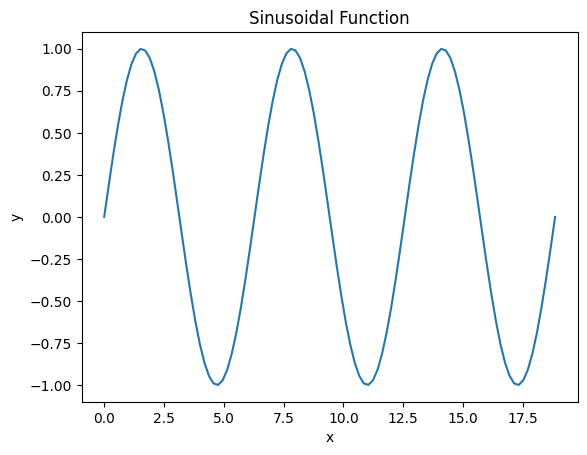

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Nous allons créer un tableau de 1000 valeurs aléatoires
n = 100
x = np.linspace(0, 6 * np.pi, n)
y = np.sin(x)

# Création du graphique
plt.plot(x, y)

# Ajout de titres et étiquettes
plt.title("Sinusoidal Function")
plt.xlabel("x")
plt.ylabel("y")

# Affichage du graphique
plt.show()

In [7]:
type(np.array([1, 2, 3, 4, 5]))  # On vérifie le type

numpy.ndarray

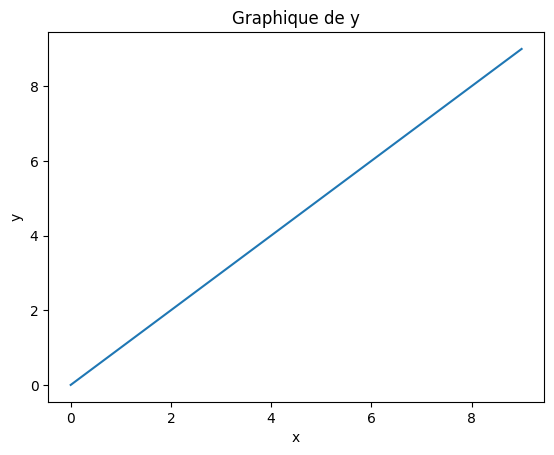

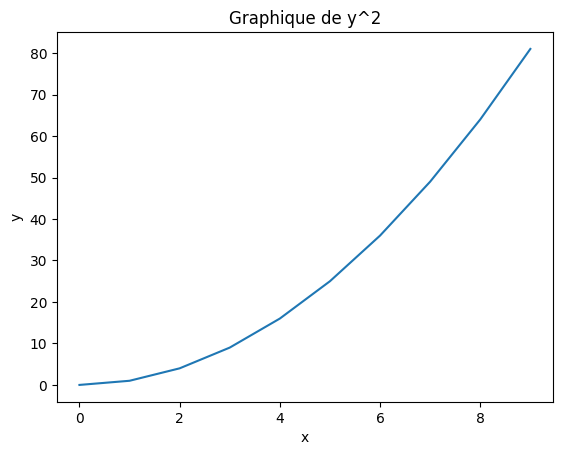

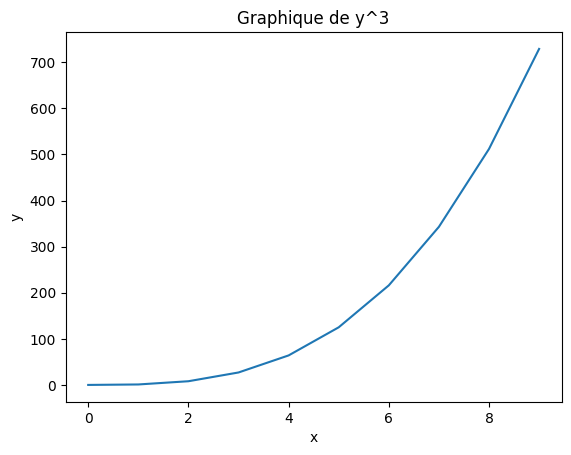

In [8]:
# On peut créer une fonction qui permet de tracer un graphique à partir d'un tableau

from typing import Optional


def tracer_graphique(
    y: np.ndarray,
    title: Optional[str] = "Graphique",
    xlabel: Optional[str] = "x",
    ylabel: Optional[str] = "y",
) -> None:
    """
    Fonction pour tracer un graphique à partir d'un tableau numpy.
    :param y: tableau numpy à tracer
    :param title (optionnel): titre du graphique
    :param xlabel (optionnel): étiquette de l'axe des x
    :param ylabel (optionnel): étiquette de l'axe des y
    :return: None
    """
    x = np.arange(len(y))
    plt.plot(x, y)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.show()


# On peut traver x, x**2, x**3

y = np.arange(10)
y_2 = y**2
y_3 = y**3

# Traçons les graphiques

tracer_graphique(y, title="Graphique de y")
tracer_graphique(y_2, title="Graphique de y^2")
tracer_graphique(y_3, title="Graphique de y^3")

### 2. Les différents types de graphiques


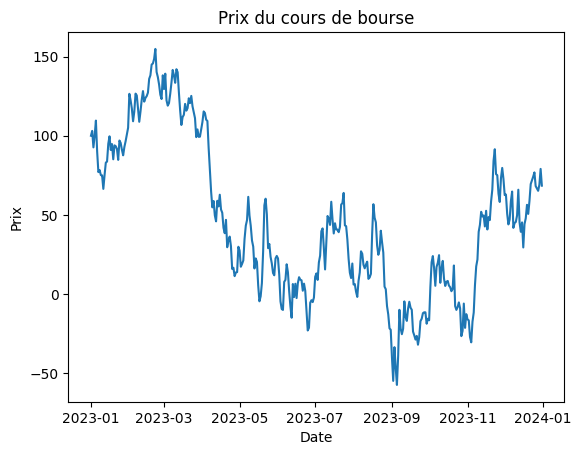

In [9]:
# Line plot: Series temporelles
# Représentation d'un prix de cours de bourse: moyenne + mouvement brownien
mean_price = 100
std_price = 10
n_days = 365

dates = np.arange("2023-01-01", "2024-01-01", dtype="datetime64[D]")
price = np.zeros(n_days)
price[0] = mean_price

generator = np.random.default_rng(
    seed=42
)  # Initialiser le générateur de nombres aléatoires

price[1:] = mean_price + np.cumsum(generator.normal(0, std_price, n_days - 1))

# Tracer le prix
plt.plot(dates, price)
plt.title("Prix du cours de bourse")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.show()

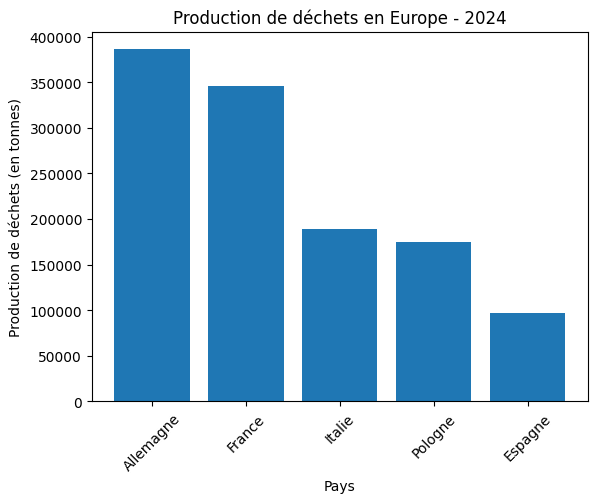

In [10]:
# Les bar plot sont utilisés pour analyser des données catégorielles
# Les 10 principaux pays européens producteurs de déchets en 2022
# Source : Eurostat, mai 2024 (https://www.statistiques.developpement-durable.gouv.fr/la-production-et-le-recyclage-des-dechets-en-france-extrait-du-bilan-environnemental-2024)
production_dechet = {
    "Allemagne": 385_795,
    "France": 345_468,
    "Italie": 189_554,
    "Pologne": 174_514,
    "Espagne": 97_011,
}

# On va tracer un bar plot avec les pays et la production de déchets
pays = list(production_dechet.keys())
production = list(production_dechet.values())
plt.bar(pays, production)
plt.title("Production de déchets en Europe - 2024")
plt.xlabel("Pays")
plt.ylabel("Production de déchets (en tonnes)")
plt.xticks(rotation=45)
plt.show()

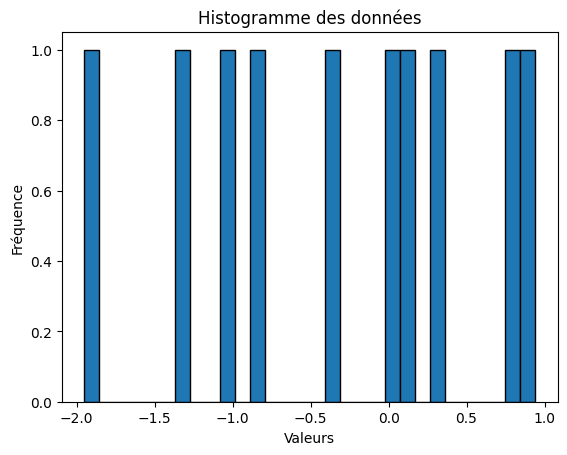

In [11]:
# Les histogrammes sont utilisés pour analyser la distribution des données
generator = np.random.default_rng(42)

# Générer des données aléatoires: Loi normale
data = generator.normal(loc=0, scale=1, size=10)

# On va tracer l'histogramme
plt.hist(data, bins=30, edgecolor="black")
plt.title("Histogramme des données")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")
plt.show()

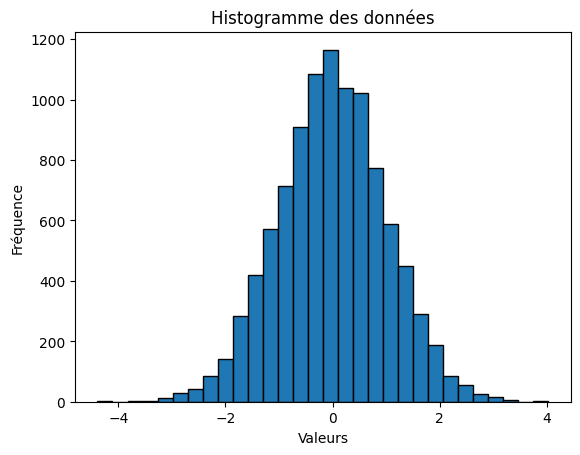

In [12]:
# En probabilité, on va souvent tirer beaucoup de réalisation de la meme loi
# pour représenter la distribution: Loi des grands nombres
# Générer des données aléatoires: Loi normale
data = generator.normal(loc=0, scale=1, size=10000)

# On va tracer l'histogramme
plt.hist(data, bins=30, edgecolor="black")
plt.title("Histogramme des données")
plt.xlabel("Valeurs")
plt.ylabel("Fréquence")
plt.show()

Text(0.5, 1.0, 'Scatter plot - x, y non corrélés')

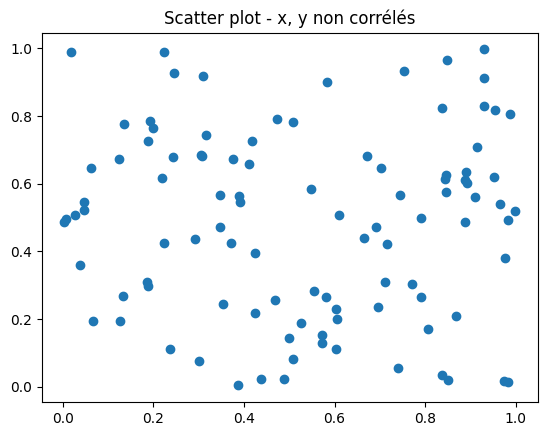

In [13]:
# Scatter plot : représenter la relation entre deux variables
x = generator.random(100)
y = generator.random(100)

# On va tracer le scatter plot
plt.scatter(x, y)
plt.title("Scatter plot - x, y non corrélés")

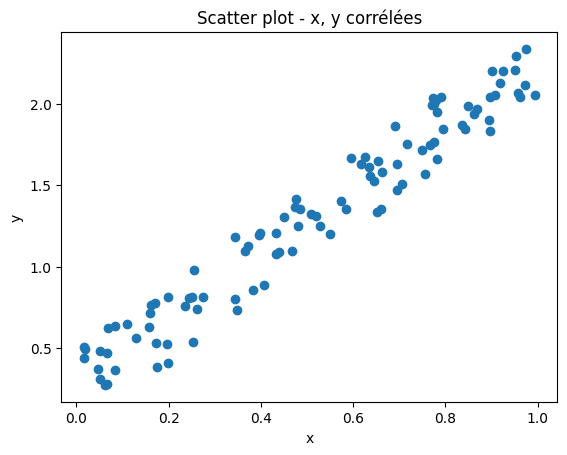

In [14]:
# Et si les données sont hautement corrélées, que se passe-t-il?
x = generator.random(100)
y = 2 * x + generator.random(100) * 0.5
# y est corrélé à x, mais pas parfaitement (il y a du bruit)

# On va tracer le scatter plot
plt.scatter(x, y)
plt.title("Scatter plot - x, y corrélées")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

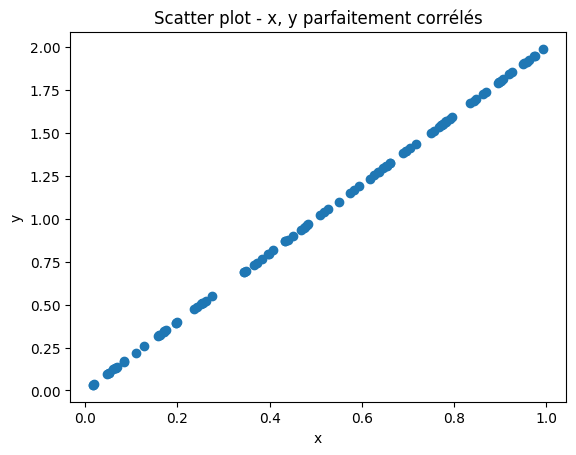

In [15]:
# Et si y est parfaitement corrélé à x?
y = 2 * x
# On va tracer le scatter plot
plt.scatter(x, y)
plt.title("Scatter plot - x, y parfaitement corrélés")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [16]:
# La notion de corrélation est fondamentale en statistique et également en
# Machine Learning !!

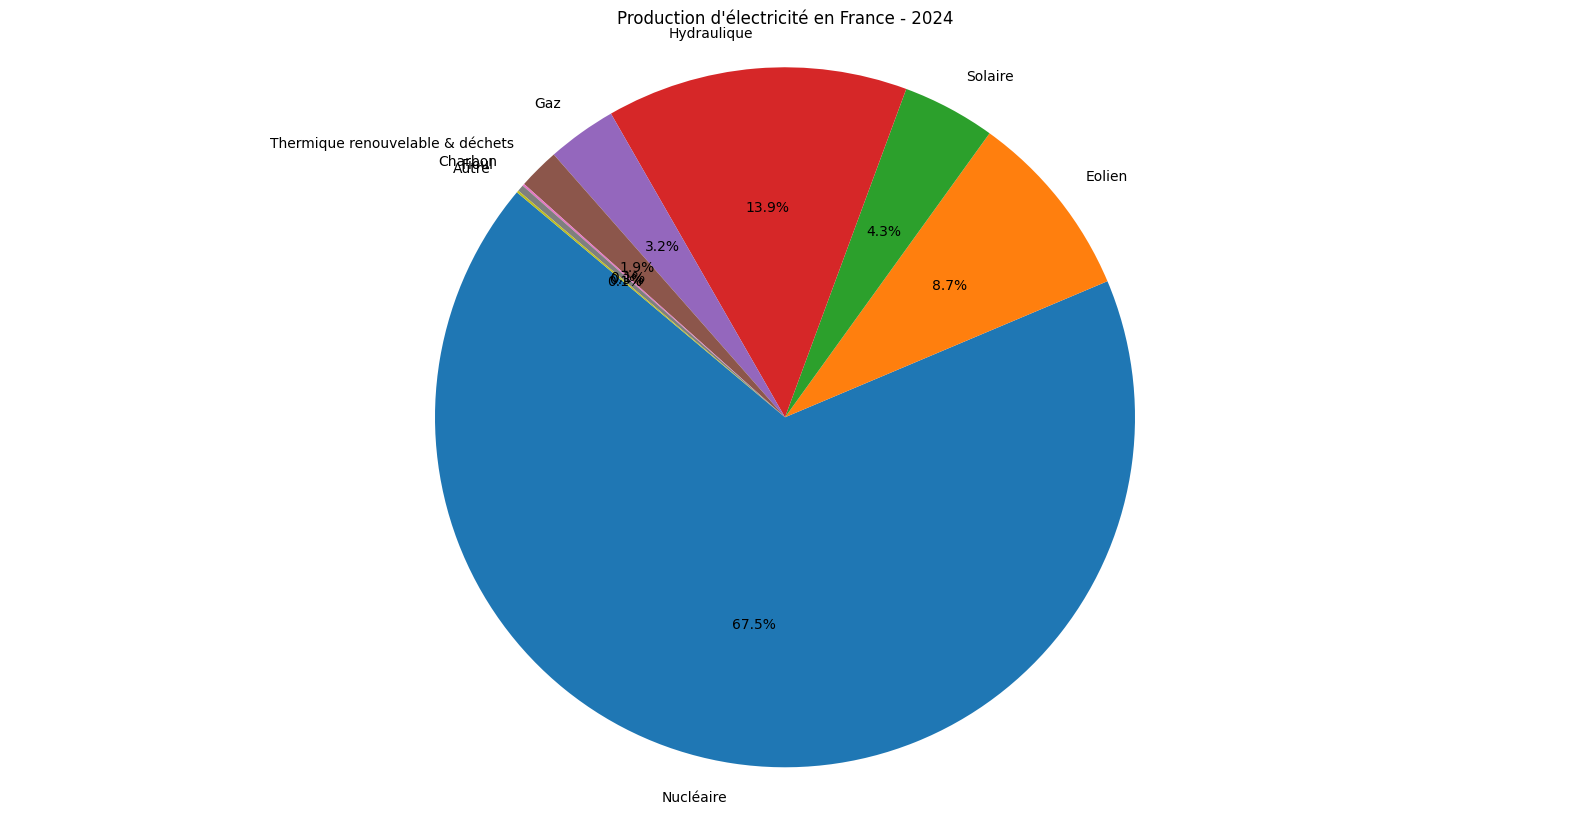

In [17]:
# Pie chart: représenter la répartition des données
# Production totale d'électricité - France 2024
# Source RTE: https://assets.rte-france.com/prod/public/2025-01/2025-01-20-chiffres-cles-production-electricite-francaise-2024.pdf
production_electricite = {
    "Nucléaire": 67.4,
    "Eolien": 8.7,
    "Solaire": 4.3,
    "Hydraulique": 13.9,
    "Gaz": 3.2,
    "Thermique renouvelable & déchets": 1.9,
    "Charbon": 0.1,
    "Fioul": 0.3,
    "Autre": 0.1,
}

# On va tracer un pie chart avec les pays et la production d'électricité
labels = list(production_electricite.keys())
sizes = list(production_electricite.values())

# On va tracer le pie chart
plt.figure(figsize=(20, 10))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140)
plt.axis("equal")  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Production d'électricité en France - 2024")
plt.xticks(rotation=45)
plt.show()

## Exercice 🐍- Choix et création de graphiques

L'objectif de cet exercice est de vous familiariser avec la création de graphiques en utilisant Matplotlib, ainsi que de choisir le type de graphique le plus approprié pour représenter vos données.

## Objectifs:
- Apprendre à créer des graphiques simples avec Matplotlib
- Apprendre à choisir le type de graphique le plus approprié pour représenter vos données

## Enoncé
Pour chaque type de données, choisissez le type de graphique le plus approprié et créez-le avec Matplotlib.

1. Données de ventes mensuelles :  Vous disposez des ventes mensuelles d'une entreprise sur une année.
    - ventes_mensuelles = [150, 200, 180, 220, 240, 260, 270, 250, 230, 210, 200, 190]

2. Répartition des dépenses par département : Vous avez les dépenses annuelles de différents départements d'une entreprise.
    - depenses = {'RH': 50000, 'Marketing': 70000, 'IT': 60000, 'Finance': 45000}

3. Relation entre le budget publicitaire et les ventes :  Vous souhaitez analyser l'impact du budget publicitaire sur les ventes.
    - budget_pub = [1000, 1500, 1300, 1800, 2000, 2400, 2900]
    - ventes = [150, 180, 165, 220, 280, 250, 300]

In [18]:
import matplotlib.pyplot as plt

# 1. Données de ventes mensuelles
ventes_mensuelle = np.array(
    [150, 200, 180, 220, 240, 260, 270, 250, 230, 210, 200, 190]
)

# 2. Répartition des dépenses par département
depenses = {"RH": 50000, "Marketing": 70000, "IT": 60000, "Finance": 45000}

# 3. Relation entre le budget publicitaire et les ventes
budget_pub = np.array([1000, 1500, 1300, 1800, 2000, 2400, 2900])
ventes = np.array([150, 180, 165, 220, 280, 250, 300])

# A vous de jouer !

### 3. Personnalisation des graphiques

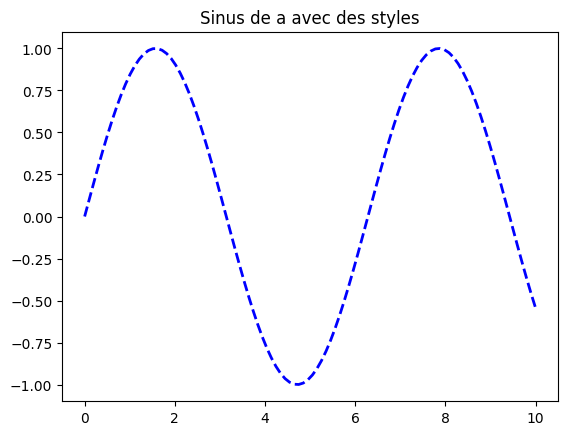

In [19]:
# On peut modifier les coulours, les styles de lignes etc ...

a = np.linspace(0, 10, 100)
b = np.sin(a)

# On va tracer le graphique
plt.plot(a, b, color="blue", linestyle="--", linewidth=2)
plt.title("Sinus de a avec des styles")
plt.show()

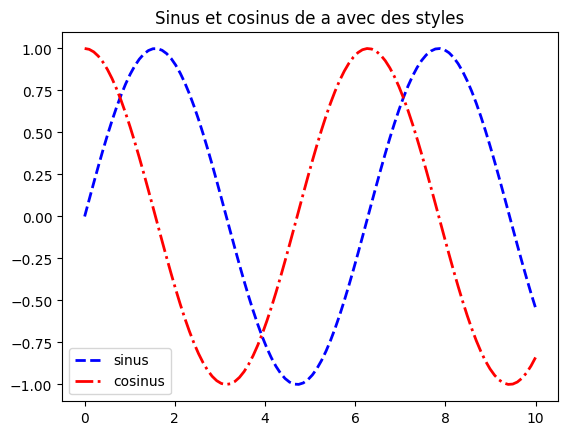

In [20]:
# On peut afficher plusieurs lignes différentes sur le même graphique avec
# des styles différents et meme la légende!
a = np.linspace(0, 10, 100)
b = np.sin(a)
c = np.cos(a)

# On va tracer le graphique
plt.plot(a, b, color="blue", linestyle="--", linewidth=2, label="sinus")
plt.plot(a, c, color="red", linestyle="-.", linewidth=2, label="cosinus")
plt.title("Sinus et cosinus de a avec des styles")
plt.legend()  # On affiche la légende
plt.show()

### 4. Sous-graphiques

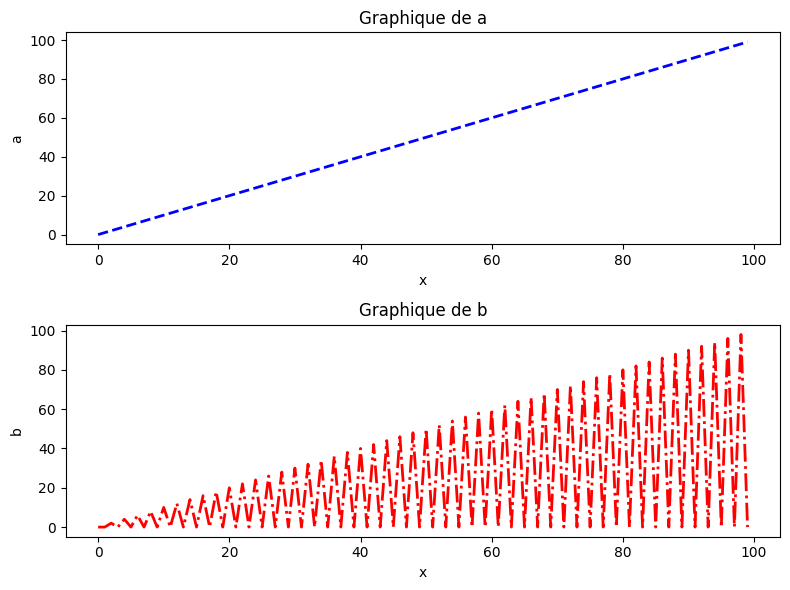

In [21]:
# Il est très simple de créer des sous-graphes avec matplotlib

a = np.arange(0, 100)
b = a.copy()
b[b % 2 == 1] = 0  # On met à zéro les valeurs impaires

# On va tracer a et b dans des sous-graphes "subplots"
fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(a, color="blue", linestyle="--", linewidth=2)
axs[0].set_title("Graphique de a")
axs[0].set_xlabel("x")
axs[0].set_ylabel("a")

axs[1].plot(b, color="red", linestyle="-.", linewidth=2)
axs[1].set_title("Graphique de b")
axs[1].set_xlabel("x")
axs[1].set_ylabel("b")
plt.tight_layout()  # Ajuste l'espacement entre les sous-graphes
plt.show()

### 5. Enregistrement des graphiques

In [22]:
a = np.arange(0, 20)
b = np.cumsum(a)  # Somme cumulée de a

In [23]:
b

array([  0,   1,   3,   6,  10,  15,  21,  28,  36,  45,  55,  66,  78,
        91, 105, 120, 136, 153, 171, 190])

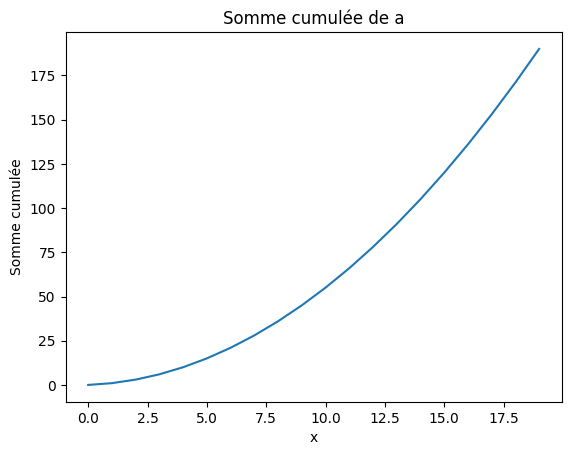

In [24]:
# Créer un plot et le sauvegarder
plt.plot(a, b)
plt.title("Somme cumulée de a")
plt.xlabel("x")
plt.ylabel("Somme cumulée")
plt.savefig("somme_cumulee.png")  # Sauvegarder le graphique
plt.show()

## Exercice 🐍 - Analyse des ventes d'une boutique

Vous êtes responsable de l'analyse des ventes d'une boutique. Vous disposez des données de ventes mensuelles pour différentes catégories de produits. Vous devez créer des visualisations pour mieux comprendre les tendances et présenter vos résultats.

## Objectifs:
- Apprendre à créer des graphiques avec Matplotlib
- Apprendre à personnaliser les graphiques
- Apprendre à créer des sous-graphiques
- Apprendre à enregistrer les graphiques

## Enoncé

1. Créez le graphique approprié montrant l'évolution des ventes totales (toutes catégories confondues) au fil des mois.

2. Sous-graphiques : Utilisez des sous-graphiques pour afficher l'évolution des ventes de chaque catégorie de produits sur une seule figure. 

3. Personnalisez chaque sous-graphique avec des couleurs et des styles de ligne différents.
Personnalisation : Ajoutez des titres, des étiquettes aux axes et une légende à chaque sous-graphique.

4. Enregistrement : Enregistrez la figure complète avec les sous-graphiques dans un fichier nommé analyse_ventes.png.

Les données représentent les ventes mensuelles (en milliers d'euros) de quatre catégories de produits (Électronique, Vêtements, Jouets, Livres) sur six mois

In [25]:
month = np.arange(1, 7)

ventes = np.array(
    [
        [150, 200, 180, 220, 240, 260],  # Jouets
        [270, 250, 230, 210, 200, 190],  # Vêtements
        [300, 320, 310, 330, 340, 350],  # Electronique
        [400, 420, 410, 430, 440, 450],  # Livres
    ]
)

# A vous de jouer !

## Exercice 🐍 - La spirale des nombres premiers

L'objectif de cet exercice est de combiner vos connaissances en mathématiques et en visualisation pour créer une spirale de nombres premiers.

cf : [Why do prime numbers make these spirals? - 3Blue1Brown](https://www.youtube.com/watch?v=EK32jo7i5LQ)

Sur un graphique en coordonnées polaires, chaque couple (x, x) avec x un nombre premier est représenté par un point. La spirale est formée lorsqu'on trace les points en ordre croissant de x.

## Objectifs:
- Choisir le type de graphique le plus approprié pour représenter vos données

## Enoncé
1. Créez une fonction qui génère une liste de nombres premiers jusqu'à un certain nombre n.
2. Créez une fonction qui génère les coordonnées x et y des nombres premiers pour former une spirale. (x = y)
3. Utilisez Matplotlib pour tracer la spirale des nombres premiers.
4. Personnalisez le graphique en ajoutant des titres, des étiquettes aux axes et une légende.
5. Enregistrez le graphique dans un fichier nommé spirale_nombres_premiers.png.


In [ ]:
# A vous de jouer !